# Scanpy (python) tutorial
## Ouroboros with Scanpy

Welcome to our tutorial on how to use Ouroboros with Scanpy. This tutorial will cover how to run Ouroboros and visualize the results within a Scanpy workflow. For more information on the Scanpy steps see their workflow: [https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html] or single cell best practices: [https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html]

Running Ouroboros within a scanpy workflow isn't strictly necessary, but if you want to follow this tutorial install scanpy into your ouroboros_env:
```bash
conda activate ouroboros_env
mamba install -c conda-forge "scanpy>=1.9.3,<1.11"
```

In [1]:
import ouroboros as obo
import scanpy as sc
import anndata as ad
import numpy as np
import ouroboros as obo
import importlib_resources as resources
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go

from IPython.display import IFrame



We have included a test dataset which is a subset of cells from a neurogenesis dataset published by Paun et al. [https://pubmed.ncbi.nlm.nih.gov/36931659/] which you can read in to test your ouroboros installation 

## Filtering

In [2]:
# Read in test dataset - subsetted to existing features
with resources.path("ouroboros.data", "neurogen_example.h5ad") as path:
    adata = sc.read_h5ad(path)
    
adata

AnnData object with n_obs × n_vars = 400 × 60649
    obs: 'cell_type'
    layers: 'raw_counts', 'spliced', 'unspliced'

We have provided the check_genes() to test if your annadata object is missing any of the Ouroboros feature genes. If any genes are missing and you run Ouroboros, the VAE will be retrained using only the feature genes present in your matrix. This may result in lower accuracy. To ensure the model is as accurate as possible, avoid filtering out any feature genes. 

Returns a list of Ouroboros feature genes missing from your anndata. 

In [3]:
# See if any genes are missing from the annadata 
missing_genes = obo.check_genes(adata)

No feature genes are missing from your anndata


Next you can calculate your QC metrics like you normally would in Scanpy.

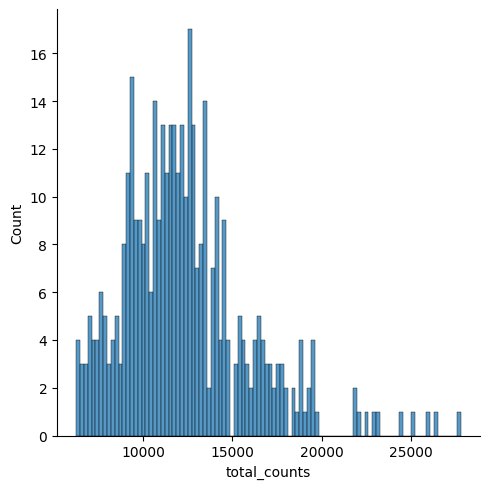

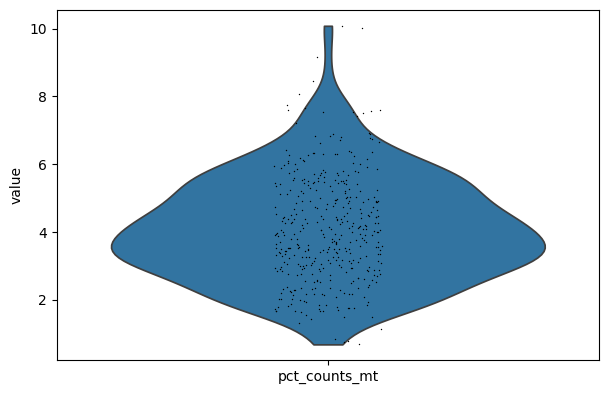

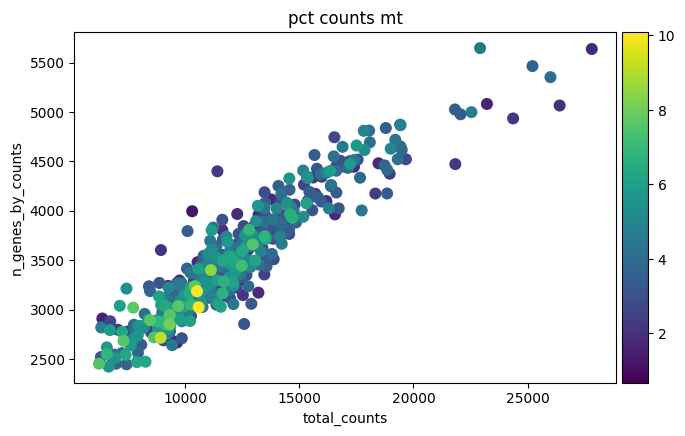

In [4]:
# Continue with nomal scanpy filtering

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

# Calculate QC metrics with scanpy 
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

# Plot QC metrics
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

After calculating QC metrics you can then set your filtering thresholds. For more information on this see single cell best practices [https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html]

In [5]:
sc.pp.filter_cells(adata, min_genes=20)
# Usually you would use Scanpy to filter genes with sc.pp.filter_genes(), but if any of our feature genes have low counts they will be removed and then the model will retrain
# If you want Ouroboros to be as accurate as possible, it's best to leave all feature genes in the matrix, even if they have low counts 

# Alternative way to filter genes to keep feature genes present:
# Read in feature genes
feature_genes = obo.read_in_features()
# Count how many cells each gene is expressed in
gene_counts = np.array((adata.X > 0).sum(axis=0)).flatten()
# Apply min_cells threshold
gene_mask = gene_counts >= 3
# Get gene names
gene_names = adata.var_names.to_numpy()
# Force-keep genes in keep_genes
gene_mask |= np.isin(gene_names, list(feature_genes))
# Subset the AnnData
adata = adata[:, gene_mask].copy()
adata

AnnData object with n_obs × n_vars = 400 × 16256
    obs: 'cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'raw_counts', 'spliced', 'unspliced'

## Run Ouroboros

Great now our object is ready to run Ouroboros! 

In [6]:
# The first step is the save a copy of your filtered adata object with adata.layers['raw_counts'] - this layer is what Ouroboros will run on

# save your raw counts 
adata.layers['raw_counts'] = adata.X.copy()

# write the adata to a H5AD
adata.write_h5ad('output_example/example.h5ad')

In [7]:
# Then you can run Ouroboros on the saved h5ad 
z_df = obo.run_ouroboros('output_example/example.h5ad', 'h5ad', species = 'human', outdir = '.')


⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠀⢀⣠⣴⡶⢿⣟⡛⣿⢉⣿⠛⢿⣯⡈⠙⣿⣦⡀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⣠⡾⠻⣧⣬⣿⣿⣿⣿⣿⡟⠉⣠⣾⣿⠿⠿⠿⢿⣿⣦⠀⠀⠀
⠀⠀⠀⠀⣠⣾⡋⣻⣾⣿⣿⣿⠿⠟⠛⠛⠛⠀⢻⣿⡇⢀⣴⡶⡄⠈⠛⠀⠀⠀
⠀⠀⠀⣸⣿⣉⣿⣿⣿⡿⠋⠀⠀⠀⠀⠀⠀⠀⠈⢿⣇⠈⢿⣤⡿⣦⠀⠀⠀⠀
⠀⠀⢰⣿⣉⣿⣿⣿⠏⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠙⠦⠀⢻⣦⠾⣆⠀⠀⠀
⠀⠀⣾⣏⣿⣿⣿⡟⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠈⣿⡶⢾⡀⠀⠀
⠀⠀⣿⠉⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣿⣧⣼⡇⠀⠀
⠀⠀⣿⡛⣿⣿⣿⡇⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣿⣧⣼⡇⠀⠀
⠀⠀⠸⡿⢻⣿⣿⣿⡄⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⢀⣼⣿⣥⣽⠁⠀⠀
⠀⠀⠀⢻⡟⢙⣿⣿⣿⣦⡀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⣠⣾⣿⣧⣸⡏⠀⠀⠀
⠀⠀⠀⠀⠻⣿⡋⣻⣿⣿⣿⣦⣤⣀⣀⣀⣀⣀⣠⣴⣿⣿⢿⣥⣼⠟⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠈⠻⣯⣤⣿⠻⣿⣿⣿⣿⣿⣿⣿⣿⣿⠛⣷⣴⡿⠋⠀⠀⠀⠀⠀
⠀⠀⠀⠀⠀⠀⠀⠈⠙⠛⠾⣧⣼⣟⣉⣿⣉⣻⣧⡿⠟⠋⠁⠀⠀⠀⠀⠀⠀⠀
⠀⠀⠀Sphere visualization complete⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀⠀


Alternatively you can run this on the command line:

```bash
conda activate ouroboros_env
```

```bash 
ouroboros \
    --data example.h5ad  \
    --data_type h5ad \
    --species human \
    --outdir output_example
```

And then just read in z_df from the output directory
```python
z_df = pd.read_csv('ouroboros_embeddings_pseudotimes.csv')
```


z_df contains:
**dim1, dim2, dim3:** 3D spherical coordinates representing the position of each cell in VAE latent space
**KNN_phase:** Discrete phase predictions output by Ouroboros based on KNN of each cell to the reference dataset in VAE latent space 
**cell_cycle_pseudotime:** Continuous cell cycle pseudotime values. Ranges from 0 - 1. 
**dormancy_depth:** Continuous dormancy depth values. Ranges from 0 to -1. In our manuscript cells with dormancy depth < -0.6 appeared to more senescent-like, where cells with > -0.6 appeared more quiescent-like. 



## Plotting Ouroboros sphere

Plots of KNN phase, dormancy depth and cell cycle pseudotime are included in the ouroboros output folder, but if you want to make your own plots you can do so with our function plot_sphere()

```python
plot_sphere(
    z_df: pd.DataFrame,
    colour_by: str = 'KNN_phase',
    palette: dict | str = None,
    ref: pd.DataFrame = None,
    velocity: pd.DataFrame = None,
    marker_size: int = 2,
    savefig: str = None,
    show: bool = False
)
```



| Parameter     | Type            | Description                                                                                                                                                         |
| ------------- | --------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `z_df`        | `DataFrame`     | The main cell dataframe with 3D spherical coordinates (`dim1`, `dim2`, `dim3`) and metadata columns such as phase labels or pseudotime.                             |
| `colour_by`   | `str`           | Column in `z_df` to color points by (e.g. `'KNN_phase'`, `'cell_cycle_pseudotime'`, `'dormancy_depth'`).                                                            |
| `palette`     | `dict` or `str` | Optional color map: dictionary for categorical data (e.g {`'G1'`: `'blue'`, `'G2M'`: `'green'`}), or colormap name (e.g. `'mako'`, `'rocket_r'`) for continuous data. If `None`, an appropriate default is used. |
| `ref`         | `DataFrame`     | Optional reference dataset to overlay, with columns `dim1`, `dim2`, `dim3`, and `phase`. If model was retrained, pass outdir/retrain/0/ouroboros_embeddings_pseudotimes.csv. If model was not retrained, pass 'default'. If None is passed no reference points will be plotted.                                                                             |
| `velocity`    | `DataFrame`     | Optional velocity vectors with columns `dim1`, `dim2`, `dim3`.                                                                                                      |
| `marker_size` | `int`           | Size of scatter points.                                                                                                                                             |
| `savefig`     | `str`           | If provided, saves the plot as an HTML file to this path.                                                                                                           |
| `show`        | `bool`          | Whether to display the figure in a browser (via `plotly`).                                                                                                          |

### 3D Sphere embeddings

If you were not missing any genes, and therefore did not need to re-train the model, plot like so:
- To check if the model was retrained, see if outdir/retrained_reference_embeddings.csv exists in your Ouroboros output directory - if not, the model was not retrained, your cells were simply embedded in the full model outlined in our paper. 

In [ ]:
# We did not need to retrain the VAE in this tutorial, so to include reference embedding points we can just give 'default' for the arg ref:
obo.plot_sphere(z_df, colour_by = 'KNN_phase', ref = 'default', show = True, savefig = "output_example/ouroboros_KNN_sphere.html")


In [11]:
# This is just for rendering in the wiki 
IFrame(src="output_example/ouroboros_KNN_sphere.html", width="100%", height=600)

If your model was retrained (outdir/retrained_reference_embeddings.csv exists) plot like so:

In [ ]:

# If you are working with a retrained model, read in your re-trained reference embeddings like so: 
ref_embed = pd.read_csv('outdir/retrained_reference_embeddings.csv')
# set cell labels as index
ref_embed = ref_embed.set_index('Unnamed: 0')

# pass the re-trained reference embedding df to plot_sphere():
obo.plot_sphere(z_df, colour_by = 'KNN_phase', ref = ref_embed, show = True, savefig = "output_example/ouroboros_KNN_sphere.html")


Alternatively you can just plot your cells, and not include the reference cells in the plot like so:

In [ ]:
# Or you can just pass ref_embed = None to only plot your cells
obo.plot_sphere(z_df, colour_by = 'KNN_phase', ref = None, show = True, savefig = "output_example/ouroboros_KNN_sphere_no_refembed.html")

In [17]:
# This is just for rendering in the wiki 
IFrame(src="output_example/ouroboros_KNN_sphere_no_refembed.html", width="100%", height=600)

You can plot variables that are in adata but not in z_df by adding them to z_df with their index:

In [ ]:
cell_type = adata.obs[['cell_type']]

z_df = z_df.merge(cell_type, how = 'left', left_index = True, right_index = True)

obo.plot_sphere(z_df, colour_by='cell_type', ref = 'default', show=True, savefig = 'output_example/example_sphere_ct.html')

IFrame(src="../output_example/example_sphere_ct.html", width="100%", height=600)

We have also created a function to plot the expression of a gene from the adata on the sphere:

Example usage: 
```python
plot_gene_sphere(
    z_df: pd.DataFrame,
    adata: anndata.AnnData,
    gene_name: str,
    layer: str = None,
    ref: pd.DataFrame = None,
    ref_color: str = 'putative_phase_transition',
    ref_pal: dict = phase_pal_transition,
    velocity: pd.DataFrame = None,
    show: bool = False,
    outpath: str = None
)
```

| Parameter    | Type                    | Description                                                                                   |
| ------------ | ----------------------- | --------------------------------------------------------------------------------------------- |
| `z_df`       | `DataFrame`             | DataFrame containing embedded cell coordinates (`dim1`, `dim2`, `dim3`) and metadata columns. |
| `adata`      | `AnnData`               | The original single-cell data object containing expression values.                            |
| `gene_name`  | `str`                   | Gene to plot. Must exist in `adata.var_names`.                                                |
| `layer`      | `str`, optional         | Name of the `.layers` slot in `adata` to use (e.g. `"log_counts"`). Defaults to `.X`.         |
| `ref`        | `DataFrame`, optional   | Optional reference cells with `dim1`, `dim2`, `dim3`, and metadata like phase.                |
| `velocity`   | `DataFrame`, optional   | Optional velocity vectors (same shape as `z_df`) with `dim1`, `dim2`, `dim3`.  See plot_velocity for more information.               |
| `show`       | `bool`, default `False` | Whether to display the plot interactively in a Jupyter notebook.                                                    |
| `outpath`    | `str`, optional         | If provided, saves the interactive Plotly figure as HTML.                                     |


In [22]:
fig = obo.plot_gene_sphere(z_df, adata, gene_name = 'TOP2A', ref = ref_embed, show = False, outpath = 'output_example/example_sphere_top2a.html')

IFrame(src="output_example/example_sphere_top2a.html", width="100%", height=600)


## 2D Sphere snapshot plot

We have also included a function to take a still snapshot of the sphere and output a png. For this the user provides latitude and longitude values that specify where on the sphere the camera will be looking. You may need to adjust the radius to get the sphere looking nice in the snapshot - when retraining the sphere is not bound to a set size, so it could potentially be quite large and require a large radius to 'see' properly. 

Example usage: 
```python
sphere_snapshot(
    lat: int,
    long: int, 
    z_df: pd.DataFrame,
    colour_by: str, 
    radius: float, 
    gene_name: str,
    layer: str = None,
    ref_embed: pd.DataFrame = None,
    vel_df: pd.DataFrame = None,
    save_as_png: str # ex. /path/to/output/png
    cycle_pole: list[float] = [0,0,1]
)
```
| Parameter     | Type                      | Description                                                                                                                               |
| ------------- | ------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- |
| `lat`         | `int`                     | Latitude angle (in degrees) to position the camera viewpoint. Must be in `[-90, 90]`.                                                     |
| `lon`         | `int`                     | Longitude angle (in degrees) to position the camera viewpoint. Must be in `[0, 360]`.                                                     |
| `z_df`        | `DataFrame`               | DataFrame containing spherical embedding coordinates (`dim1`, `dim2`, `dim3`) and metadata.                                               |
| `colour_by`   | `str`                     | Column in `z_df` to color points by (e.g., `'KNN_phase'`, `'cell_cycle_pseudotime'`).                                                     |
| `radius`      | `float`, optional         | Distance from the sphere center to the virtual camera. Controls zoom level.                                                               |
| `palette`     | `dict` or `str`, optional | Color palette. Use a dictionary for categorical values or a colormap name (e.g., `'mako'`) for continuous values.                         |
| `ref_embed`   | `DataFrame`, optional     | Optional reference dataset with `dim1`, `dim2`, `dim3`, and metadata columns (e.g., `phase`). Used for transparent background points.     |
| `vel_df`      | `DataFrame`, optional     | Optional velocity vectors with columns `dim1`, `dim2`, `dim3`. Drawn as arrows and cones.                                                 |
| `save_as_png` | `str`, optional           | Path to save the image as a PNG. If `None`, the image is not saved.                                                                       |
| `showlegend`  | `bool`, default `False`   | Whether to display the legend in the plot.                                                                                                |
| `cycle_pole`  | `list[float]`, optional   | 3D vector indicating the cell cycle pole. Defaults to `[0, 0, 1]`.|


In [28]:
# Make your snapshot
obo.sphere_snapshot(0, 0, z_df = z_df, colour_by='dormancy_pseudotime', radius = 5, ref_embed = 'default', vel_df = None, save_as_png='output_example/dormancy_depth.png')


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


<img src="output_example/dormancy_depth.png" width="350">

## 2D 'Map'/Robinson projection

We have included a function to plot the sphere as a stretched out 'map' or robinson projection. 

```python
plot_robinson_projection(
    z_df=embedding_df,
    colour_by='cell_cycle_pseudotime',
    palette='rocket_r',
    ref_df=reference_df,
    title="Differentiation Trajectory",
    scale=15,
    save_fig="robinson.png"
)
```

**Parameters:**
| Parameter           | Type                      | Description                                                                                                                                             |
| ------------------- | ------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| `z_df`              | `DataFrame`               | DataFrame containing 3D spherical embedding coordinates (`dim1`, `dim2`, `dim3`) and associated metadata for coloring.                                  |
| `colour_by`         | `str`                     | Column in `z_df` to color by. Automatically handled as categorical (e.g., `'KNN_phase'`) or continuous (e.g., `'cell_cycle_pseudotime'`).                                        |
| `palette`           | `dict` or `str`, optional | Custom palette: a dict mapping labels to colors for categorical data, or a colormap name (e.g., `'mako'`, `'viridis'`) for continuous data. If `None`, a colormap is auto-selected (`rocket_r` for `cell_cycle_pseudotime`, `mako` for `dormancy_pseudotime`, else `viridis`; `tab20`/`phase_pal_transition` for categorical). |
| `ref_df`            | `DataFrame`, optional     | Optional reference DataFrame with `dim1`, `dim2`, `dim3` and a `phase` column. Plotted as faint background points colored by phase.                    |
| `central_longitude` | `int`, default `80`       | Longitude (in degrees) to center the Robinson projection.                                                                                              |
| `title`             | `str`, optional           | Title of the plot.                                                                                                                                     |
| `alpha`             | `float`, default `0.7`    | Transparency of the primary data points.                                                                                                               |
| `scale`             | `float`, default `10`     | Scale of the velocity vector arrows (larger values produce shorter arrows).                                                                            |
| `save_fig`          | `str`, optional           | File path to save the figure to (300 dpi, tight bounding box). If `None`, the figure is not saved.                                                     |
| `rasterize`         | `bool`, default `True`    | Whether to rasterize the scatter and quiver layers, keeping file sizes small when plotting many points while leaving axes/text as vectors.             |
| `show`              | `bool`, default `True`    | Whether to display the figure with `plt.show()`.                                                                                                       |


TypeError: string indices must be integers

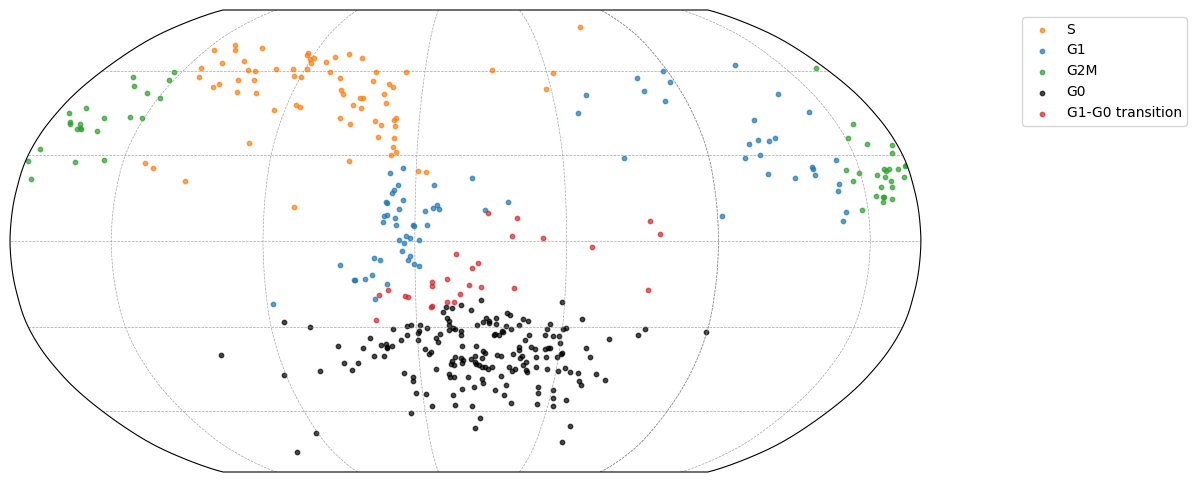

In [31]:
# Make plot with discrete variable 
# set palette
phase_pal_transition = {
    'G1':'#1f77b4',
       'S': '#ff7f0e',
       'G2M': '#2ca02c', 
       'G0': 'black', 
       'G1-G0 transition': '#d62728'}

# plot
obo.plot_robinson_projection(
    z_df=z_df,
    colour_by='KNN_phase',
    palette=phase_pal_transition,
    ref_df='default',
    title="Robinson",
    scale=15,
    save_fig="output_example/robinson.png"
)

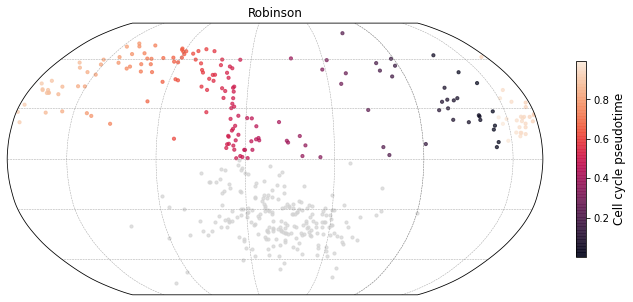

In [ ]:
# Make plot with continous variable 
obo.plot_robinson_projection(
    z_df=z_df_rotated,
    colour_by='cell_cycle_pseudotime',
    palette="rocket",
    ref_df=None,
    title="Robinson",
    scale=15,
    save_fig="output_example/robinson.png")

## Continue Scanpy workflow and plot on UMAP

You can also proceed with a standard scanpy workflow, and plot KNN_phase, cell_cycle_pseudotime and dormancy_depth on a PCA or UMAP. 

In [ ]:
# First add KNN_phase, cell_cycle_pseudotime and dormancy_depth to adata.obs

adata.obs = adata.obs.merge(z_df[['KNN_phase', 'cell_cycle_pseudotime', 'dormancy_depth']], how = 'left', left_index = True, right_index = True)

### PCA

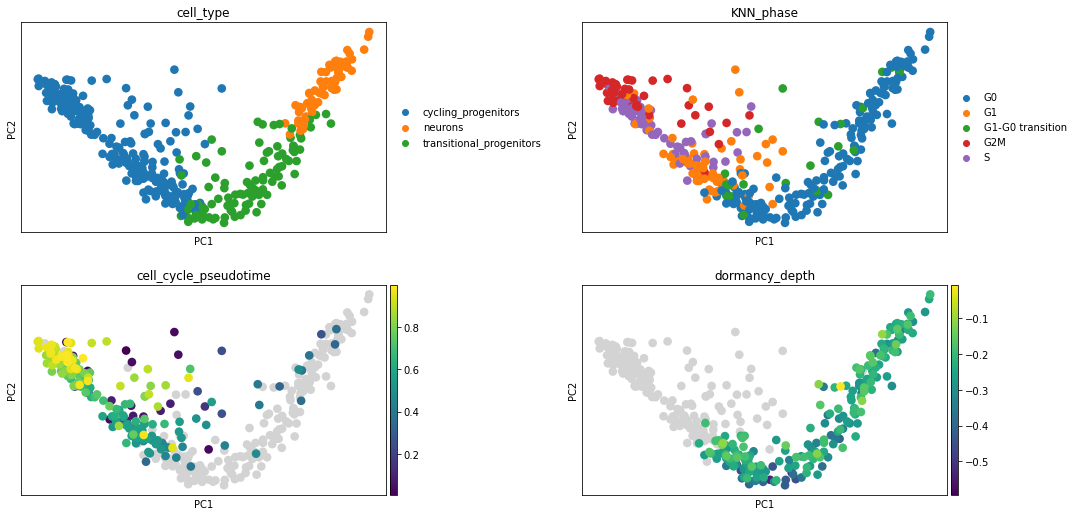

In [ ]:
# Code from Scanpy's clustering tutorial [https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html]

# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

# Feature selection
sc.pp.highly_variable_genes(adata)

#PCA
sc.tl.pca(adata)

sc.pl.pca(
    adata,
    color=["cell_type", "KNN_phase", 'cell_cycle_pseudotime', 'dormancy_depth'],
    ncols=2,
    wspace=0.4
)


### UMAP

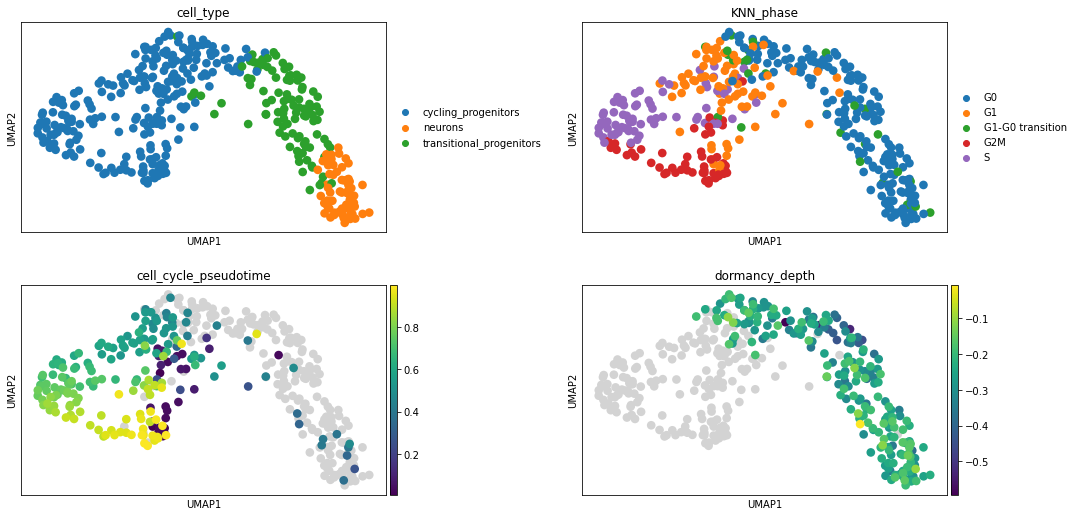

In [ ]:
# Nearest neighbour graph construction and visualization 
sc.pp.neighbors(adata)

sc.tl.umap(adata)

sc.pl.umap(
    adata,
    color=["cell_type", "KNN_phase", 'cell_cycle_pseudotime', 'dormancy_depth'],
    ncols=2,
    wspace=0.4
)

## RNA velocity

Please see our RNA velocity in the Ouroboros sphere tutorial for more information